# Early Fusion Person1

Saving BATCH1_96.xlsx to BATCH1_96.xlsx
Raw data shape: (96, 55)

All columns:
['clip', 'label', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r', 'AU01_c', 'AU02_c', 'AU04_c', 'AU05_c', 'AU06_c', 'AU07_c', 'AU09_c', 'AU10_c', 'AU12_c', 'AU14_c', 'AU15_c', 'AU17_c', 'AU20_c', 'AU23_c', 'AU25_c', 'AU26_c', 'AU28_c', 'AU45_c', 'gaze_angle_x', 'gaze_angle_y', 'pose_Rx', 'pose_Ry', 'pose_Rz', 'bpm', 'ibi', 'sdnn', 'sdsd', 'rmssd', 'pnn20', 'pnn50', 'hr_mad', 'sd1', 'sd2', 's', 'sd1/sd2', 'breathingrate']

Cleaned data shape: (96, 55)
Unique clips: 16

Label distribution:
label
0    24
1    30
2    18
3    24
Name: count, dtype: int64

===== Feature Split =====
OpenFace columns (40):
['AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r', 'AU01_c', 'AU02_c', '

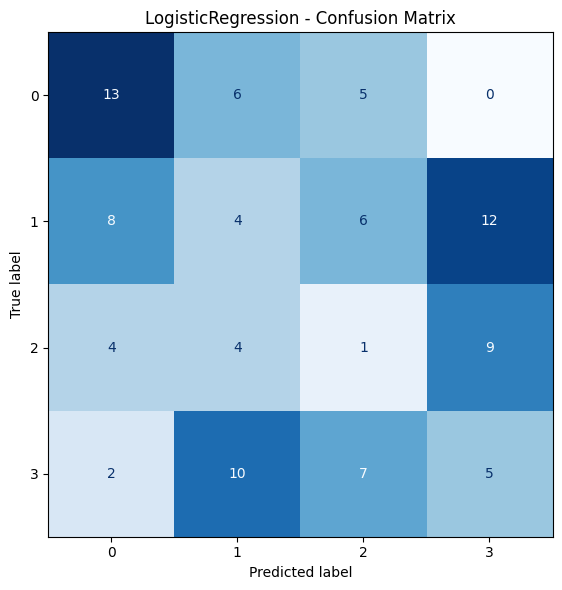

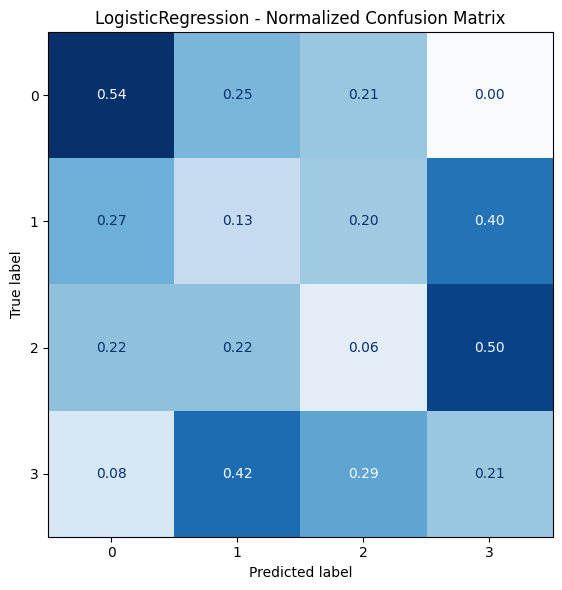


Selected features for LogisticRegression (full-data refit, interpretability only):
          selected_feature
0         openface__AU01_r
1         openface__AU06_r
2         openface__AU09_r
3         openface__AU14_r
4         openface__AU15_r
5         openface__AU20_r
6         openface__AU23_r
7         openface__AU25_r
8         openface__AU26_r
9         openface__AU01_c
10        openface__AU02_c
11        openface__AU07_c
12        openface__AU10_c
13        openface__AU12_c
14        openface__AU14_c
15        openface__AU17_c
16        openface__AU23_c
17        openface__AU25_c
18  openface__gaze_angle_y
19       openface__pose_Rz

Running model: LinearSVM
Fold 01 | Test clip: 1 | n_test=6 | Acc=1.0000, BAcc=1.0000, Macro-F1=1.0000
Fold 02 | Test clip: 2 | n_test=6 | Acc=0.1667, BAcc=0.1667, Macro-F1=0.0714
Fold 03 | Test clip: 3 | n_test=6 | Acc=0.8333, BAcc=0.8333, Macro-F1=0.4545
Fold 04 | Test clip: 4 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 05 | Test 

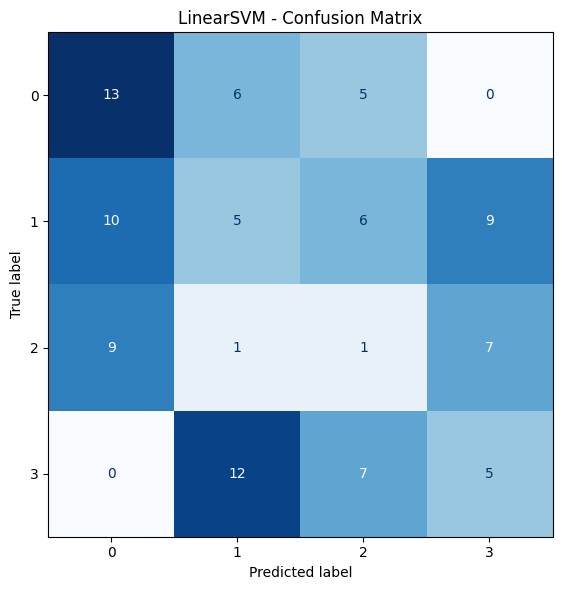

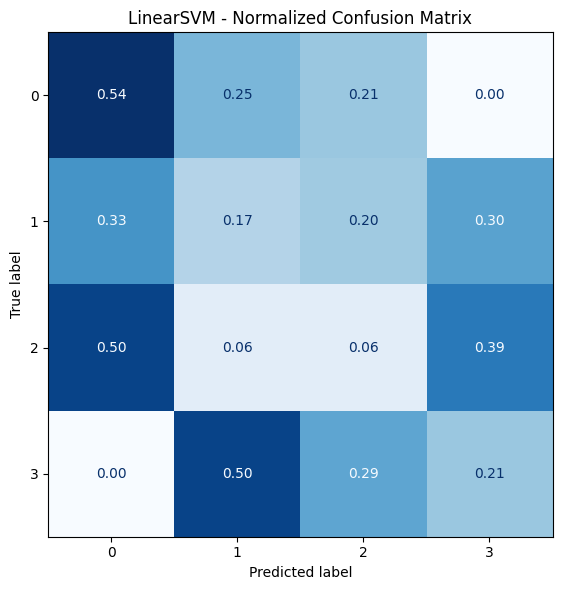


Selected features for LinearSVM (full-data refit, interpretability only):
          selected_feature
0         openface__AU01_r
1         openface__AU06_r
2         openface__AU09_r
3         openface__AU14_r
4         openface__AU15_r
5         openface__AU20_r
6         openface__AU23_r
7         openface__AU25_r
8         openface__AU26_r
9         openface__AU01_c
10        openface__AU02_c
11        openface__AU07_c
12        openface__AU10_c
13        openface__AU12_c
14        openface__AU14_c
15        openface__AU17_c
16        openface__AU23_c
17        openface__AU25_c
18  openface__gaze_angle_y
19       openface__pose_Rz

Running model: RandomForest
Fold 01 | Test clip: 1 | n_test=6 | Acc=1.0000, BAcc=1.0000, Macro-F1=1.0000
Fold 02 | Test clip: 2 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 03 | Test clip: 3 | n_test=6 | Acc=1.0000, BAcc=1.0000, Macro-F1=1.0000
Fold 04 | Test clip: 4 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 05 | Test clip: 

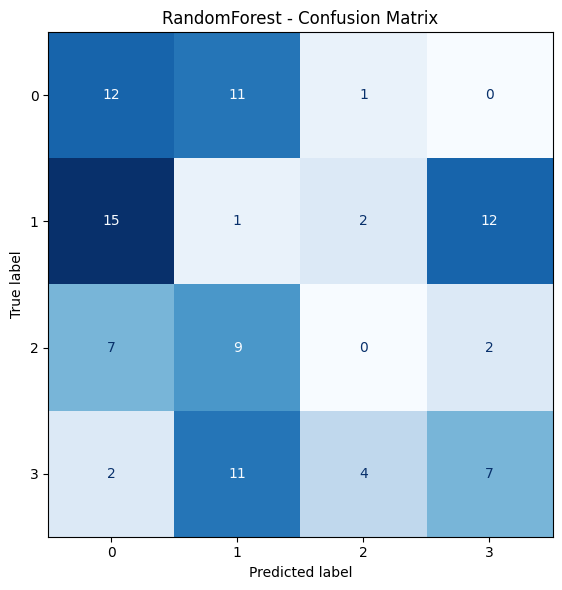

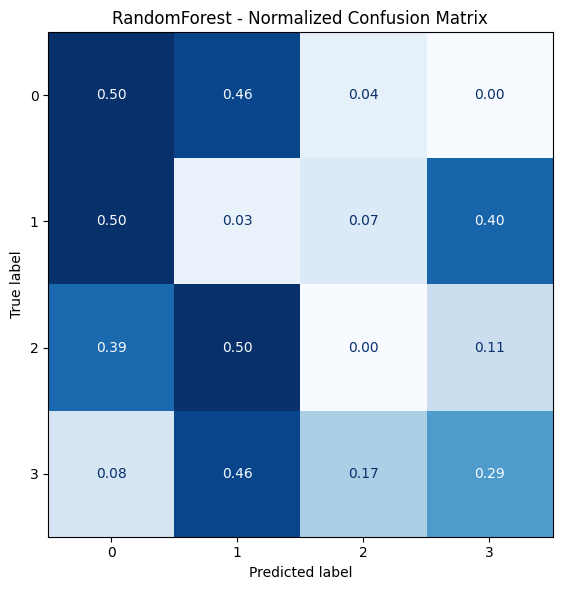


Selected features for RandomForest (full-data refit, interpretability only):
          selected_feature
0         openface__AU01_r
1         openface__AU06_r
2         openface__AU09_r
3         openface__AU14_r
4         openface__AU15_r
5         openface__AU20_r
6         openface__AU23_r
7         openface__AU25_r
8         openface__AU26_r
9         openface__AU01_c
10        openface__AU02_c
11        openface__AU07_c
12        openface__AU10_c
13        openface__AU12_c
14        openface__AU14_c
15        openface__AU17_c
16        openface__AU23_c
17        openface__AU25_c
18  openface__gaze_angle_y
19       openface__pose_Rz

ALL MODEL FOLD RESULTS
                 model  fold  test_clip  n_train  n_test  accuracy  \
0   LogisticRegression     1          1       90       6  1.000000   
1   LogisticRegression     2          2       90       6  0.166667   
2   LogisticRegression     3          3       90       6  0.833333   
3   LogisticRegression     4          4       90   

In [ ]:
# =========================================
# Early Fusion + LOVO + 3-Model Comparison
# OpenFace + PPG
# Models:
#   1) Logistic Regression
#   2) Linear SVM
#   3) Random Forest
# =========================================
from google.colab import files
uploaded = files.upload()
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# =========================
# Config
# =========================
DATA_PATH = Path("BATCH1_96.xlsx")
OUTPUT_DIR = Path("early_fusion_lovo_3models_outputs_1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TOP_K_FEATURES = 20

# =========================
# 1. Load data
# =========================
df = pd.read_excel(DATA_PATH)

print("Raw data shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())

# =========================
# 2. Basic cleaning
# =========================
required_cols = ["clip", "label"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

df = df.dropna(axis=1, how="all").copy()

df = df.dropna(subset=["clip", "label"]).reset_index(drop=True)

print("\nCleaned data shape:", df.shape)
print("Unique clips:", df["clip"].nunique())
print("\nLabel distribution:")
print(df["label"].value_counts(dropna=False).sort_index())

# =========================
# 3. Define feature columns
# =========================
ppg_cols_known = [
    "bpm", "ibi", "sdnn", "sdsd", "rmssd",
    "pnn20", "pnn50", "hr_mad", "sd1", "sd2",
    "s", "sd1/sd2", "breathingrate"
]

ppg_cols = [c for c in ppg_cols_known if c in df.columns]

exclude_cols = ["clip", "label"]
candidate_feature_cols = [c for c in df.columns if c not in exclude_cols]

openface_cols = [c for c in candidate_feature_cols if c not in ppg_cols]

openface_cols = [c for c in openface_cols if pd.api.types.is_numeric_dtype(df[c])]
ppg_cols = [c for c in ppg_cols if pd.api.types.is_numeric_dtype(df[c])]

if len(openface_cols) == 0:
    raise ValueError("No OpenFace numeric columns found.")
if len(ppg_cols) == 0:
    raise ValueError("No PPG numeric columns found.")

feature_cols = openface_cols + ppg_cols

print("\n===== Feature Split =====")
print(f"OpenFace columns ({len(openface_cols)}):")
print(openface_cols)

print(f"\nPPG columns ({len(ppg_cols)}):")
print(ppg_cols)

print(f"\nTotal feature columns: {len(feature_cols)}")

# =========================
# 4. Build X / y / groups
# =========================
X = df[feature_cols].copy()
y_raw = df["label"].copy()
groups = df["clip"].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = [str(c) for c in label_encoder.classes_]

print("\nEncoded classes:")
for i, c in enumerate(class_names):
    print(f"{i} -> {c}")

# =========================
# 5. Preprocessing (modality-specific)
# =========================
openface_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ppg_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# early fusion: ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("openface", openface_transformer, openface_cols),
        ("ppg", ppg_transformer, ppg_cols),
    ],
    remainder="drop"
)

# =========================
# 6. Define 3 ML architectures
# =========================
models = {
    "LogisticRegression": LogisticRegression(
        C=0.1,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "LinearSVM": LinearSVC(
        C=0.1,
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

# =========================
# 7. LOVO evaluation
# =========================
logo = LeaveOneGroupOut()

all_model_fold_results = []
all_model_summary = []

for model_name, classifier in models.items():
    print(f"\n{'='*60}")
    print(f"Running model: {model_name}")
    print(f"{'='*60}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(
            score_func=mutual_info_classif,
            k=min(TOP_K_FEATURES, len(feature_cols))
        )),
        ("classifier", classifier)
    ])

    fold_results = []
    pooled_true = []
    pooled_pred = []
    pooled_test_indices = []

    # LOVO
    for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups=groups), start=1
    ):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        test_clip = groups.iloc[test_idx].iloc[0]

        # train + predict
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        bacc = balanced_accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

        fold_results.append({
            "model": model_name,
            "fold": fold_idx,
            "test_clip": test_clip,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": acc,
            "balanced_accuracy": bacc,
            "macro_f1": macro_f1,
        })

        pooled_true.extend(y_test.tolist())
        pooled_pred.extend(y_pred.tolist())
        pooled_test_indices.extend(test_idx.tolist())

        print(
            f"Fold {fold_idx:02d} | Test clip: {test_clip} | "
            f"n_test={len(test_idx)} | "
            f"Acc={acc:.4f}, BAcc={bacc:.4f}, Macro-F1={macro_f1:.4f}"
        )

    fold_df = pd.DataFrame(fold_results)
    all_model_fold_results.append(fold_df)

    fold_df.to_csv(OUTPUT_DIR / f"{model_name}_fold_results.csv", index=False)

    # pooled overall metrics
    pooled_true = np.array(pooled_true)
    pooled_pred = np.array(pooled_pred)

    pooled_acc = accuracy_score(pooled_true, pooled_pred)
    pooled_bacc = balanced_accuracy_score(pooled_true, pooled_pred)
    pooled_macro_f1 = f1_score(pooled_true, pooled_pred, average="macro", zero_division=0)

    summary_row = {
        "model": model_name,
        "fold_accuracy_mean": fold_df["accuracy"].mean(),
        "fold_accuracy_std": fold_df["accuracy"].std(ddof=1),
        "fold_bacc_mean": fold_df["balanced_accuracy"].mean(),
        "fold_bacc_std": fold_df["balanced_accuracy"].std(ddof=1),
        "fold_macro_f1_mean": fold_df["macro_f1"].mean(),
        "fold_macro_f1_std": fold_df["macro_f1"].std(ddof=1),
        "pooled_accuracy": pooled_acc,
        "pooled_balanced_accuracy": pooled_bacc,
        "pooled_macro_f1": pooled_macro_f1,
    }
    all_model_summary.append(summary_row)

    # classification report
    report_dict = classification_report(
        pooled_true,
        pooled_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(OUTPUT_DIR / f"{model_name}_classification_report.csv")

    print(f"\n{model_name} classification report:")
    print(report_df)

    # confusion matrix
    cm = confusion_matrix(pooled_true, pooled_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    # normalized confusion matrix
    cm_norm = confusion_matrix(pooled_true, pooled_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    plt.title(f"{model_name} - Normalized Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
    plt.show()

    # pooled predictions
    pred_df = df.loc[pooled_test_indices, ["clip", "label"]].copy()
    pred_df["y_true_encoded"] = pooled_true
    pred_df["y_pred_encoded"] = pooled_pred
    pred_df["y_true_name"] = [class_names[i] for i in pooled_true]
    pred_df["y_pred_name"] = [class_names[i] for i in pooled_pred]
    pred_df.to_csv(OUTPUT_DIR / f"{model_name}_pooled_predictions.csv", index=False)

    pipeline.fit(X, y)
    selector = pipeline.named_steps["feature_selection"]
    selected_mask = selector.get_support()

    feature_names_after_preprocess = pipeline.named_steps["preprocessor"].get_feature_names_out()
    selected_feature_names = feature_names_after_preprocess[selected_mask]

    selected_features_df = pd.DataFrame({
        "selected_feature": selected_feature_names
    })
    selected_features_df.to_csv(
        OUTPUT_DIR / f"{model_name}_selected_features_full_refit.csv",
        index=False
    )

    print(f"\nSelected features for {model_name} (full-data refit, interpretability only):")
    print(selected_features_df)

# =========================
# 8. Merge all results
# =========================
all_folds_df = pd.concat(all_model_fold_results, ignore_index=True)
summary_df = pd.DataFrame(all_model_summary)

print("\n" + "="*60)
print("ALL MODEL FOLD RESULTS")
print("="*60)
print(all_folds_df)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(summary_df)

all_folds_df.to_csv(OUTPUT_DIR / "all_model_fold_results.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "model_comparison_summary.csv", index=False)

# =========================
# 9. Optional ranking
# =========================
summary_ranked = summary_df.sort_values(
    by=["pooled_macro_f1", "pooled_balanced_accuracy", "pooled_accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("RANKED MODEL SUMMARY")
print("="*60)
print(summary_ranked)

summary_ranked.to_csv(OUTPUT_DIR / "model_comparison_summary_ranked.csv", index=False)

print("\nAll outputs saved to:", OUTPUT_DIR.resolve())

# Early fusion Person2

Saving BATCH2_96.xlsx to BATCH2_96.xlsx
Raw data shape: (96, 55)

All columns:
['clip', 'label', 'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r', 'AU01_c', 'AU02_c', 'AU04_c', 'AU05_c', 'AU06_c', 'AU07_c', 'AU09_c', 'AU10_c', 'AU12_c', 'AU14_c', 'AU15_c', 'AU17_c', 'AU20_c', 'AU23_c', 'AU25_c', 'AU26_c', 'AU28_c', 'AU45_c', 'gaze_angle_x', 'gaze_angle_y', 'pose_Rx', 'pose_Ry', 'pose_Rz', 'bpm', 'ibi', 'sdnn', 'sdsd', 'rmssd', 'pnn20', 'pnn50', 'hr_mad', 'sd1', 'sd2', 's', 'sd1/sd2', 'breathingrate']

Cleaned data shape: (96, 55)
Unique clips: 16

Label distribution:
label
0    30
1     6
2    36
3    24
Name: count, dtype: int64

===== Feature Split =====
OpenFace columns (40):
['AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r', 'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r', 'AU01_c', 'AU02_c', '

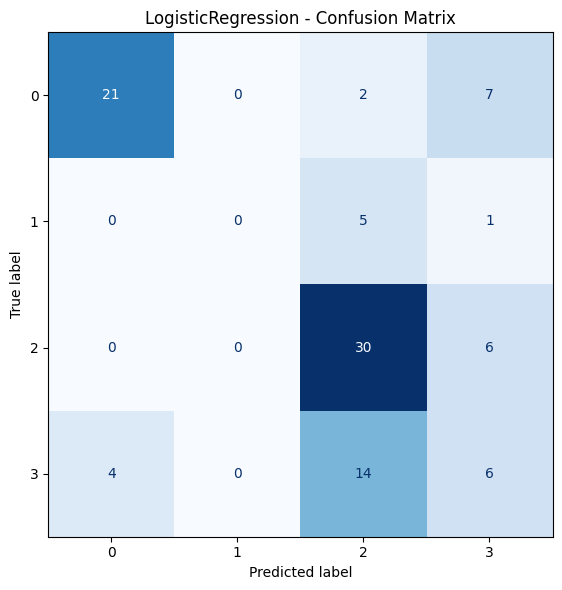

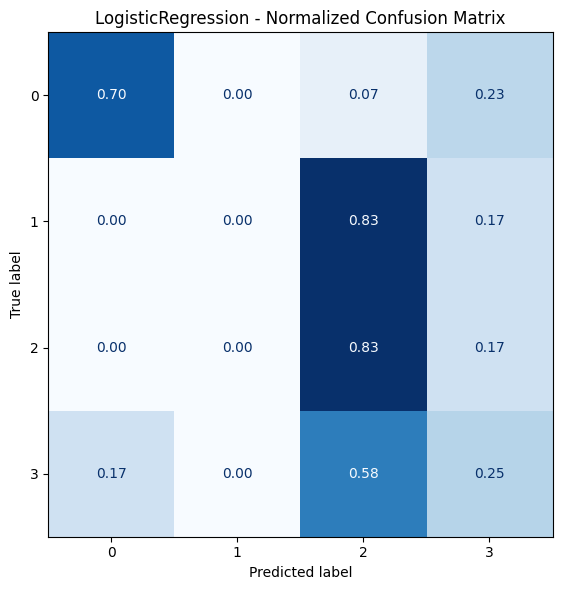


Selected features for LogisticRegression (full-data refit, interpretability only):
    selected_feature
0   openface__AU04_r
1   openface__AU06_r
2   openface__AU07_r
3   openface__AU10_r
4   openface__AU12_r
5   openface__AU25_r
6   openface__AU01_c
7   openface__AU02_c
8   openface__AU04_c
9   openface__AU05_c
10  openface__AU06_c
11  openface__AU07_c
12  openface__AU09_c
13  openface__AU10_c
14  openface__AU12_c
15  openface__AU14_c
16  openface__AU15_c
17  openface__AU20_c
18  openface__AU25_c
19  openface__AU26_c

Running model: LinearSVM
Fold 01 | Test clip: 1 | n_test=6 | Acc=1.0000, BAcc=1.0000, Macro-F1=1.0000
Fold 02 | Test clip: 2 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 03 | Test clip: 3 | n_test=6 | Acc=0.1667, BAcc=0.1667, Macro-F1=0.1429
Fold 04 | Test clip: 4 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 05 | Test clip: 5 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 06 | Test clip: 6 | n_test=6 | Acc=0.5000, BAcc=0.5000, Mac

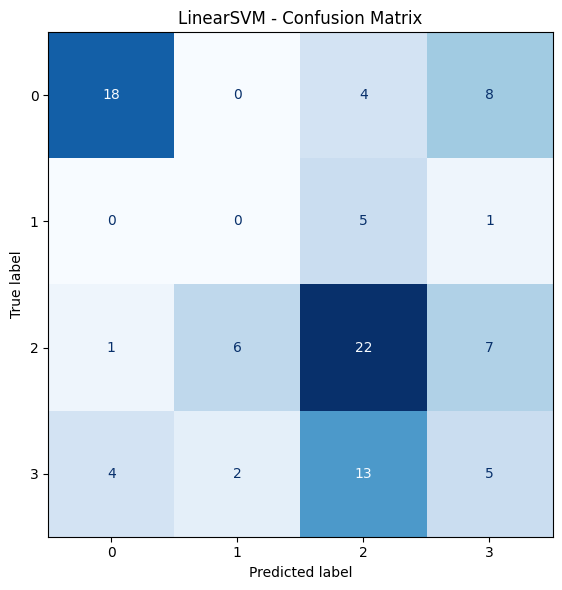

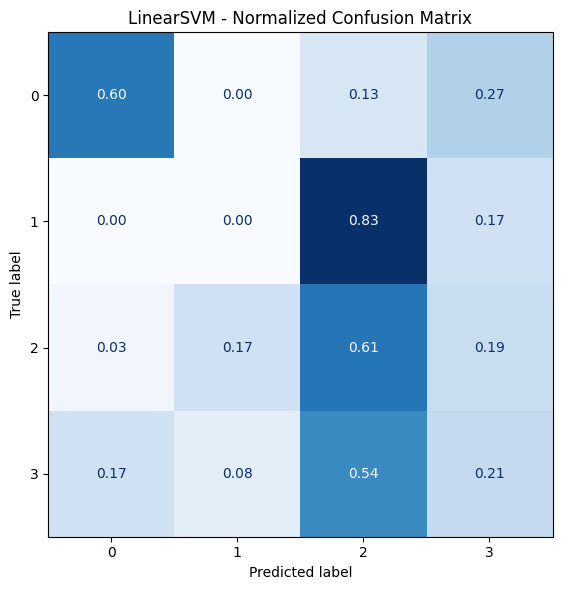


Selected features for LinearSVM (full-data refit, interpretability only):
    selected_feature
0   openface__AU04_r
1   openface__AU06_r
2   openface__AU07_r
3   openface__AU09_r
4   openface__AU10_r
5   openface__AU12_r
6   openface__AU25_r
7   openface__AU01_c
8   openface__AU02_c
9   openface__AU04_c
10  openface__AU05_c
11  openface__AU06_c
12  openface__AU07_c
13  openface__AU09_c
14  openface__AU10_c
15  openface__AU12_c
16  openface__AU14_c
17  openface__AU15_c
18  openface__AU20_c
19  openface__AU25_c

Running model: RandomForest
Fold 01 | Test clip: 1 | n_test=6 | Acc=1.0000, BAcc=1.0000, Macro-F1=1.0000
Fold 02 | Test clip: 2 | n_test=6 | Acc=1.0000, BAcc=1.0000, Macro-F1=1.0000
Fold 03 | Test clip: 3 | n_test=6 | Acc=0.1667, BAcc=0.1667, Macro-F1=0.1429
Fold 04 | Test clip: 4 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 05 | Test clip: 5 | n_test=6 | Acc=0.0000, BAcc=0.0000, Macro-F1=0.0000
Fold 06 | Test clip: 6 | n_test=6 | Acc=0.8333, BAcc=0.8333, Macro-F1=

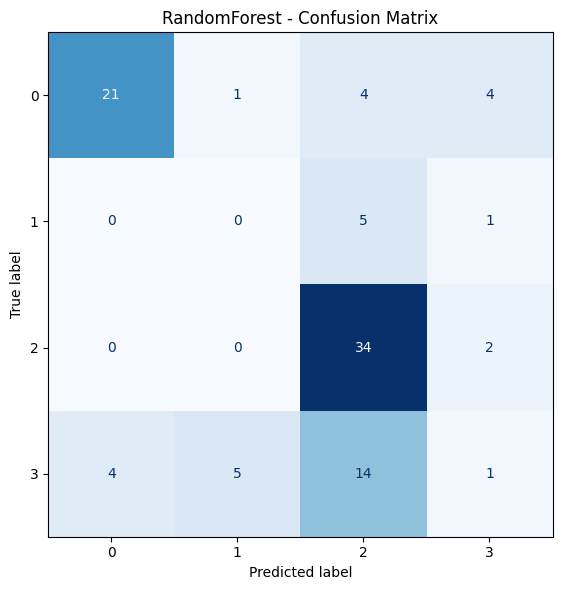

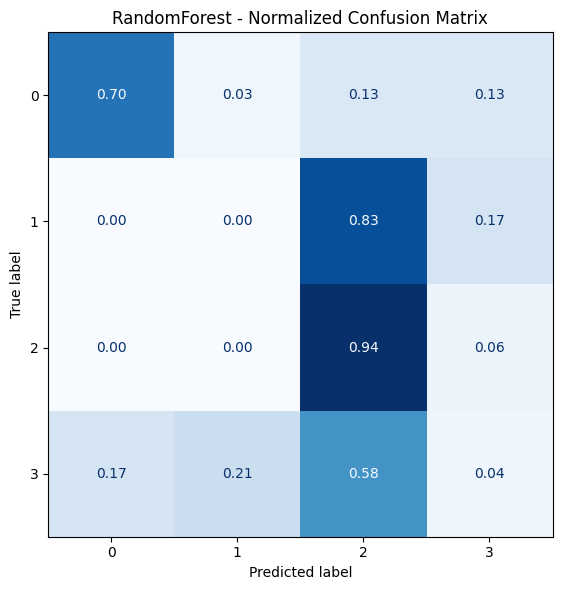


Selected features for RandomForest (full-data refit, interpretability only):
    selected_feature
0   openface__AU04_r
1   openface__AU06_r
2   openface__AU07_r
3   openface__AU10_r
4   openface__AU12_r
5   openface__AU14_r
6   openface__AU25_r
7   openface__AU01_c
8   openface__AU02_c
9   openface__AU04_c
10  openface__AU05_c
11  openface__AU06_c
12  openface__AU07_c
13  openface__AU09_c
14  openface__AU10_c
15  openface__AU12_c
16  openface__AU14_c
17  openface__AU15_c
18  openface__AU25_c
19  openface__AU26_c

ALL MODEL FOLD RESULTS
                 model  fold  test_clip  n_train  n_test  accuracy  \
0   LogisticRegression     1          1       90       6  1.000000   
1   LogisticRegression     2          2       90       6  0.666667   
2   LogisticRegression     3          3       90       6  0.333333   
3   LogisticRegression     4          4       90       6  0.000000   
4   LogisticRegression     5          5       90       6  0.000000   
5   LogisticRegression     6         

In [ ]:
# =========================================
# Early Fusion + LOVO + 3-Model Comparison
# OpenFace + PPG
# Models:
#   1) Logistic Regression
#   2) Linear SVM
#   3) Random Forest
# =========================================
from google.colab import files
uploaded = files.upload()
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# =========================
# Config
# =========================
DATA_PATH = Path("BATCH2_96.xlsx")
OUTPUT_DIR = Path("early_fusion_lovo_3models_outputs_2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TOP_K_FEATURES = 20

# =========================
# 1. Load data
# =========================
df = pd.read_excel(DATA_PATH)

print("Raw data shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())

# =========================
# 2. Basic cleaning
# =========================
required_cols = ["clip", "label"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

df = df.dropna(axis=1, how="all").copy()

df = df.dropna(subset=["clip", "label"]).reset_index(drop=True)

print("\nCleaned data shape:", df.shape)
print("Unique clips:", df["clip"].nunique())
print("\nLabel distribution:")
print(df["label"].value_counts(dropna=False).sort_index())

# =========================
# 3. Define feature columns
# =========================
ppg_cols_known = [
    "bpm", "ibi", "sdnn", "sdsd", "rmssd",
    "pnn20", "pnn50", "hr_mad", "sd1", "sd2",
    "s", "sd1/sd2", "breathingrate"
]

ppg_cols = [c for c in ppg_cols_known if c in df.columns]

exclude_cols = ["clip", "label"]
candidate_feature_cols = [c for c in df.columns if c not in exclude_cols]

# OpenFace
openface_cols = [c for c in candidate_feature_cols if c not in ppg_cols]

openface_cols = [c for c in openface_cols if pd.api.types.is_numeric_dtype(df[c])]
ppg_cols = [c for c in ppg_cols if pd.api.types.is_numeric_dtype(df[c])]

if len(openface_cols) == 0:
    raise ValueError("No OpenFace numeric columns found.")
if len(ppg_cols) == 0:
    raise ValueError("No PPG numeric columns found.")

feature_cols = openface_cols + ppg_cols

print("\n===== Feature Split =====")
print(f"OpenFace columns ({len(openface_cols)}):")
print(openface_cols)

print(f"\nPPG columns ({len(ppg_cols)}):")
print(ppg_cols)

print(f"\nTotal feature columns: {len(feature_cols)}")

# =========================
# 4. Build X / y / groups
# =========================
X = df[feature_cols].copy()
y_raw = df["label"].copy()
groups = df["clip"].copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = [str(c) for c in label_encoder.classes_]

print("\nEncoded classes:")
for i, c in enumerate(class_names):
    print(f"{i} -> {c}")

# =========================
# 5. Preprocessing (modality-specific)
# =========================
openface_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ppg_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# early fusion: ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("openface", openface_transformer, openface_cols),
        ("ppg", ppg_transformer, ppg_cols),
    ],
    remainder="drop"
)

# =========================
# 6. Define 3 ML architectures
# =========================
models = {
    "LogisticRegression": LogisticRegression(
        C=0.1,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "LinearSVM": LinearSVC(
        C=0.1,
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

# =========================
# 7. LOVO evaluation
# =========================
logo = LeaveOneGroupOut()

all_model_fold_results = []
all_model_summary = []

for model_name, classifier in models.items():
    print(f"\n{'='*60}")
    print(f"Running model: {model_name}")
    print(f"{'='*60}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(
            score_func=mutual_info_classif,
            k=min(TOP_K_FEATURES, len(feature_cols))
        )),
        ("classifier", classifier)
    ])

    fold_results = []
    pooled_true = []
    pooled_pred = []
    pooled_test_indices = []

    # LOVO
    for fold_idx, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups=groups), start=1
    ):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]

        test_clip = groups.iloc[test_idx].iloc[0]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        bacc = balanced_accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

        fold_results.append({
            "model": model_name,
            "fold": fold_idx,
            "test_clip": test_clip,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": acc,
            "balanced_accuracy": bacc,
            "macro_f1": macro_f1,
        })

        pooled_true.extend(y_test.tolist())
        pooled_pred.extend(y_pred.tolist())
        pooled_test_indices.extend(test_idx.tolist())

        print(
            f"Fold {fold_idx:02d} | Test clip: {test_clip} | "
            f"n_test={len(test_idx)} | "
            f"Acc={acc:.4f}, BAcc={bacc:.4f}, Macro-F1={macro_f1:.4f}"
        )

    fold_df = pd.DataFrame(fold_results)
    all_model_fold_results.append(fold_df)

    fold_df.to_csv(OUTPUT_DIR / f"{model_name}_fold_results.csv", index=False)

    # pooled overall metrics
    pooled_true = np.array(pooled_true)
    pooled_pred = np.array(pooled_pred)

    pooled_acc = accuracy_score(pooled_true, pooled_pred)
    pooled_bacc = balanced_accuracy_score(pooled_true, pooled_pred)
    pooled_macro_f1 = f1_score(pooled_true, pooled_pred, average="macro", zero_division=0)

    summary_row = {
        "model": model_name,
        "fold_accuracy_mean": fold_df["accuracy"].mean(),
        "fold_accuracy_std": fold_df["accuracy"].std(ddof=1),
        "fold_bacc_mean": fold_df["balanced_accuracy"].mean(),
        "fold_bacc_std": fold_df["balanced_accuracy"].std(ddof=1),
        "fold_macro_f1_mean": fold_df["macro_f1"].mean(),
        "fold_macro_f1_std": fold_df["macro_f1"].std(ddof=1),
        "pooled_accuracy": pooled_acc,
        "pooled_balanced_accuracy": pooled_bacc,
        "pooled_macro_f1": pooled_macro_f1,
    }
    all_model_summary.append(summary_row)

    # classification report
    report_dict = classification_report(
        pooled_true,
        pooled_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(OUTPUT_DIR / f"{model_name}_classification_report.csv")

    print(f"\n{model_name} classification report:")
    print(report_df)

    # confusion matrix
    cm = confusion_matrix(pooled_true, pooled_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

    # normalized confusion matrix
    cm_norm = confusion_matrix(pooled_true, pooled_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    plt.title(f"{model_name} - Normalized Confusion Matrix")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
    plt.show()

    # pooled predictions
    pred_df = df.loc[pooled_test_indices, ["clip", "label"]].copy()
    pred_df["y_true_encoded"] = pooled_true
    pred_df["y_pred_encoded"] = pooled_pred
    pred_df["y_true_name"] = [class_names[i] for i in pooled_true]
    pred_df["y_pred_name"] = [class_names[i] for i in pooled_pred]
    pred_df.to_csv(OUTPUT_DIR / f"{model_name}_pooled_predictions.csv", index=False)

    pipeline.fit(X, y)
    selector = pipeline.named_steps["feature_selection"]
    selected_mask = selector.get_support()

    feature_names_after_preprocess = pipeline.named_steps["preprocessor"].get_feature_names_out()
    selected_feature_names = feature_names_after_preprocess[selected_mask]

    selected_features_df = pd.DataFrame({
        "selected_feature": selected_feature_names
    })
    selected_features_df.to_csv(
        OUTPUT_DIR / f"{model_name}_selected_features_full_refit.csv",
        index=False
    )

    print(f"\nSelected features for {model_name} (full-data refit, interpretability only):")
    print(selected_features_df)

# =========================
# 8. Merge all results
# =========================
all_folds_df = pd.concat(all_model_fold_results, ignore_index=True)
summary_df = pd.DataFrame(all_model_summary)

print("\n" + "="*60)
print("ALL MODEL FOLD RESULTS")
print("="*60)
print(all_folds_df)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(summary_df)

all_folds_df.to_csv(OUTPUT_DIR / "all_model_fold_results.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "model_comparison_summary.csv", index=False)

# =========================
# 9. Optional ranking
# =========================
summary_ranked = summary_df.sort_values(
    by=["pooled_macro_f1", "pooled_balanced_accuracy", "pooled_accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("RANKED MODEL SUMMARY")
print("="*60)
print(summary_ranked)

summary_ranked.to_csv(OUTPUT_DIR / "model_comparison_summary_ranked.csv", index=False)

print("\nAll outputs saved to:", OUTPUT_DIR.resolve())